In [2]:
include("PermBasis.jl")
include("PlotSetup.jl")
include("MonteCarloMF.jl")
using PyPlot
using DifferentialEquations
using JLD2

legend_kwargs = (
    fontsize=12,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0
)


(fontsize = 12, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0)

In [ ]:
function generate_fig2a_data(; N = 10000, time_factor = 200, N_traj = 400, n_bg = 10)
    params = Dict(
        "global_decay" => 1.0,
        "global_pump" => 0.0,
        "local_pump" => 0.0,
        "local_dephasing" => 0.5 * N,
        "local_decay" => 0.0 * N,
    )

    tmax = time_factor * log(N) / N

    bg_trajectories = Vector{Tuple{Vector{Float64}, Vector{Float64}}}(undef, n_bg)
    for j in 1:n_bg
        times, sol = simulate_ensemble(
            N,
            params["global_decay"],
            params["local_dephasing"],
            params["local_decay"],
            tmax,
            (S, M, N, Γ, ξ) -> [S, M],
            1
        )
        bg_trajectories[j] = (
            collect(element(sol, 1) ./ N),
            collect(element(sol, 2) ./ N)
        )
    end

    times_mc, sol_mc = simulate_ensemble(
        N,
        params["global_decay"],
        params["local_dephasing"],
        params["local_decay"],
        tmax,
        (S, M, N, Γ, ξ) -> [S, M],
        N_traj
    )
    S_mc = collect(element(sol_mc, 1) ./ N)
    M_mc = collect(element(sol_mc, 2) ./ N)

    p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
    u0 = [1 / N, 1 / 2]
    prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), reltol = 1e-8, abstol = 1e-8)

    M_mf = [u[2] for u in mfsol.u]
    I_mf = [u[1] for u in mfsol.u]
    S_mf = sqrt.(I_mf .+ M_mf .^ 2)

    Sgrid = collect(range(0.0, 0.5, length = 400))
    upper_boundary = copy(Sgrid)
    lower_boundary = -Sgrid
    vertical_boundary_x = [0.5, 0.5]
    vertical_boundary_y = [-0.5, 0.5]

    return Dict(
        "N" => N,
        "time_factor" => time_factor,
        "N_traj" => N_traj,
        "n_bg" => n_bg,
        "params" => params,
        "tmax" => tmax,
        "times_mc" => collect(times_mc),
        "S_mc" => S_mc,
        "M_mc" => M_mc,
        "times_mf" => collect(mfsol.t),
        "S_mf" => S_mf,
        "M_mf" => M_mf,
        "bg_trajectories" => bg_trajectories,
        "Sgrid" => Sgrid,
        "upper_boundary" => upper_boundary,
        "lower_boundary" => lower_boundary,
        "vertical_boundary_x" => vertical_boundary_x,
        "vertical_boundary_y" => vertical_boundary_y,
    )
end

function plot_fig2a!(ax, data)
    # background trajectories
    for (S_bg, M_bg) in data["bg_trajectories"]
        ax.plot(S_bg, M_bg, color="k", alpha=0.85, linestyle="solid", linewidth=1.0)
    end

    # MC average
    ax.plot(
        data["S_mc"], data["M_mc"],
        color="blue", linestyle="solid", linewidth=2.0,
        label="MC average"
    )

    # mean field
    ax.plot(
        data["S_mf"], data["M_mf"],
        color="red", linestyle="solid", linewidth=2.0,
        label="MF"
    )

    # Dicke triangle
    ax.plot(data["Sgrid"], data["upper_boundary"], "k--", linewidth=1.5)
    ax.plot(data["Sgrid"], data["lower_boundary"], "k--", linewidth=1.5)
    ax.plot(data["vertical_boundary_x"], data["vertical_boundary_y"], "k--", linewidth=1.5)

    ax.set_xlabel(L"S/N")
    ax.set_ylabel(L"M/N")
    ax.legend(loc="lower left"; legend_kwargs...)

    return ax
end

function generate_compare_mc_mf_intensity_data(; N=30000, t_fac=20, N_traj=1000, rs=range(0.0, 1.1, 10))
    tmax = t_fac * log(N) / N

    curves = Vector{NamedTuple}(undef, length(rs))

    for (i, r) in enumerate(rs)
        ts_mc, intens_mc = simulate_ensemble(
            N, 1.0, r * N, 0.0, tmax,
            (S, M, N, Γ, ξ) -> [(S + M) * (S - M + 1)],
            N_traj
        )
        I_mc = element(intens_mc, 1) ./ N^2

        p = [1.0, r * N, N, 0.0]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
        sol_mf = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-8,
            abstol=1e-8,
            saveat=range(0.0, tmax, 2000)
        )

        I_mf = [u[1] for u in sol_mf.u]

        curves[i] = (
            r = Float64(r),
            ts_mc = collect(ts_mc),
            I_mc = collect(I_mc),
            ts_mf = collect(sol_mf.t),
            I_mf = collect(I_mf),
        )
    end

    return (
        N = N,
        t_fac = t_fac,
        N_traj = N_traj,
        rs = collect(Float64.(rs)),
        tmax = tmax,
        curves = curves,
    )
end


function plot_compare_mc_mf_intensity!(ax, data; cmap_name="viridis")
    cmap = get_cmap(cmap_name)
    rs = data["rs"]
    norm = matplotlib.colors.Normalize(vmin=minimum(rs), vmax=maximum(rs))

    for curve in data["curves"]
        r = curve.r
        color = cmap(norm(r))

        ax.plot(
            curve.ts_mc, curve.I_mc;
            color = color,
            linestyle = "-",
            linewidth = 2.0,
        )

        ax.plot(
            curve.ts_mf, curve.I_mf;
            color = color,
            linestyle = "--",
            linewidth = 1.2,
            alpha = 0.8,
        )
    end

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(L"t")
    ax.set_ylabel(L"I/N^2")
    ax.set_ylim(1e-5, 1)

    # method legend
    mc_proxy, = ax.plot([], []; color = "black", linestyle = "-", linewidth = 2.0)
    mf_proxy, = ax.plot([], []; color = "black", linestyle = "--", linewidth = 1.2)

    leg1 = ax.legend(
        [mc_proxy, mf_proxy],
        [L"\mathrm{MC}", L"\mathrm{MF}"];
        loc = "lower left",
        legend_kwargs...
    )

    # g_xi legend
    r_proxies = Any[]
    r_labels = Any[]

    for r in rs
        color = cmap(norm(r))
        proxy, = ax.plot([], []; color = color, linestyle = "-", linewidth = 2.0)
        push!(r_proxies, proxy)
        push!(r_labels, "\$g_\\xi=$(r)\$")
    end

    leg2 = ax.legend(
        r_proxies,
        r_labels;
        loc = "upper right",
        legend_kwargs...
    )

    ax.add_artist(leg1)

    return ax
end

function generate_dephasing_main_scan(;
    Ns = [1000, 10000, 50000],
    N_traj = 500,
    rs = range(0.0, 2.0, 300),
    g = 0.0,
    time_factor = 50.0,
    outfile = "../plot_data/dephasing_main_scan.jld2",
    save_progress = false,
)
    mf_intens = zeros(length(rs), length(Ns))
    mc_intens = zeros(length(rs), length(Ns))
    mf_t = zeros(length(rs), length(Ns))
    mc_t = zeros(length(rs), length(Ns))

    for (i, r) in enumerate(rs)
        println("Main scan: r = $(round(r, digits=4)) [$i/$(length(rs))]")
        for (j, N) in enumerate(Ns)
            println("  N = $N [$j/$(length(Ns))]")

            params = Dict(
                "global_decay" => 1.0,
                "global_pump" => 0.0,
                "local_pump" => 0.0,
                "local_dephasing" => r * N,
                "local_decay" => g * N / log(N),
            )

            imc, imf, tmc, tmf = mc_vs_mf_data(N, params, N_traj; time_factor=time_factor)

            mf_intens[i, j] = imf
            mc_intens[i, j] = imc
            mf_t[i, j] = tmf
            mc_t[i, j] = tmc
        end

        if save_progress
            jldsave(outfile;
                rs = collect(rs),
                Ns = Ns,
                N_traj = N_traj,
                g = g,
                time_factor = time_factor,
                mf_intens = mf_intens,
                mc_intens = mc_intens,
                mf_t = mf_t,
                mc_t = mc_t,
            )
        end
    end

    jldsave(outfile;
        rs = collect(rs),
        Ns = Ns,
        N_traj = N_traj,
        g = g,
        time_factor = time_factor,
        mf_intens = mf_intens,
        mc_intens = mc_intens,
        mf_t = mf_t,
        mc_t = mc_t,
    )
end

function plot_dephasing_panel_a!(ax, d)
    rs = d["rs"]
    Ns = d["Ns"]
    mf_intens = d["mf_intens"]
    mc_intens = d["mc_intens"]

    ax.plot(rs, 4 .* mf_intens[:, end], color="k", label="mean field")
    for j in eachindex(Ns)
        ax.scatter(rs, mc_intens[:, j] ./ mc_intens[1, j], label=sci_label(Ns[j]))
    end

    ax.set_yscale("log")
    ax.set_ylabel(L"I/I(g_\xi=0)")
    ax.set_xlabel(L"g_\xi")
    ax.grid(true)
    ax.legend(;legend_kwargs...)

    return ax
end


function plot_dephasing_panel_b!(ax, d; cs=["red", "blue", "orange"])
    rs = d["rs"]
    Ns = d["Ns"]
    mf_t = d["mf_t"]
    mc_t = d["mc_t"]

    @assert length(cs) >= length(Ns)

    for j in eachindex(Ns)
        ax.plot(rs, mf_t[:, j] .* Ns[j] ./ log(Ns[j]), color=cs[j], linestyle="solid")
        ax.scatter(rs, mc_t[:, j] .* Ns[j] ./ log(Ns[j]), label=sci_label(Ns[j]))
    end

    ax.set_xlim(left=0.4, right=1.1)
    ax.set_ylim(bottom=1.0, top = 14)
    ax.set_yscale("log")
    ax.set_ylabel(L"t_\star \Gamma N/\log(N)")
    ax.set_xlabel(L"g_\xi")
    ax.grid(true)

    return ax
end

plot_dephasing_panel_b! (generic function with 1 method)

In [34]:
data = generate_compare_mc_mf_intensity_data(
    N = 50000,
    rs = [0.0, 0.6, 0.9, 1.05],
    t_fac = 205,
    N_traj = 1000
)

jldsave("../plot_data/fig_compare_mc_mf_intensity.jld2"; data...)

In [ ]:
data = generate_fig2a_data()
jldsave("../plot_data/fig2a_data.jld2"; data)

In [39]:
generate_dephasing_main_scan(;N_traj = 2000, time_factor = 40)

Main scan: r = 0.0 [1/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0067 [2/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0134 [3/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0201 [4/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0268 [5/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0334 [6/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0401 [7/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0468 [8/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0535 [9/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0602 [10/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0669 [11/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main scan: r = 0.0736 [12/300]
  N = 1000 [1/3]
  N = 10000 [2/3]
  N = 50000 [3/3]
Main

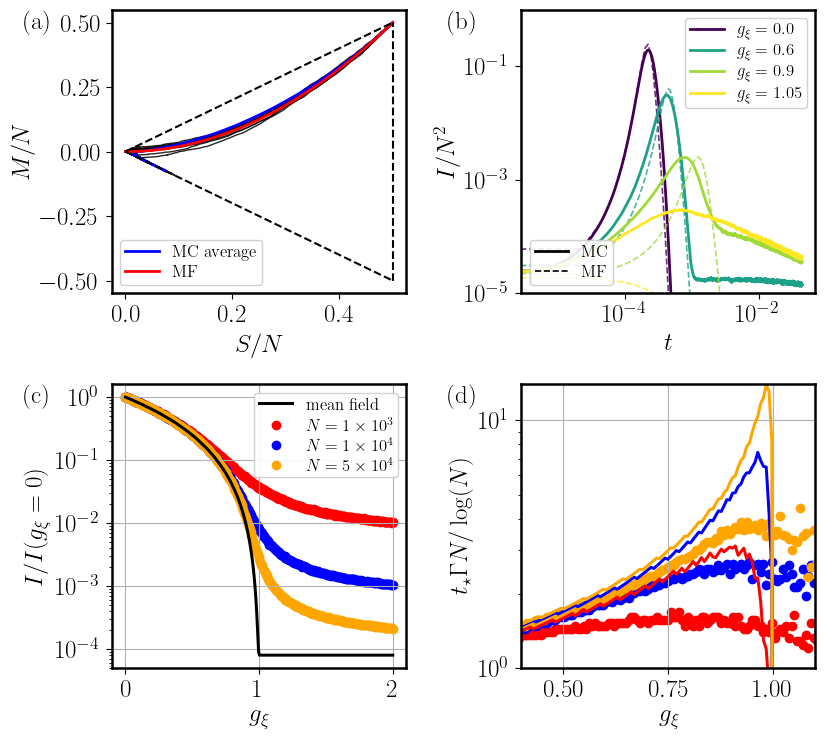

In [40]:
fig, axes = subplots(ncols = 2, nrows = 2, figsize = 2.0 .* latex_plot_setup(ratio=0.9, scale=1.8))
plot_fig2a!(axes[1], load("../plot_data/fig2a_data.jld2")["data"])
plot_compare_mc_mf_intensity!(axes[3], load("../plot_data/fig_compare_mc_mf_intensity.jld2"))
plot_dephasing_panel_a!(axes[2], load("../plot_data/dephasing_main_scan.jld2"))
plot_dephasing_panel_b!(axes[4], load("../plot_data/dephasing_main_scan.jld2"))
tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.25, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(c)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.25, 1.0, "(d)", transform=axes[2,2].transAxes, va="top")
savefig("../data/fig2.pdf", bbox_inches = "tight")
